#### Carnegie Mellon University - Tepper School of Business
#### 46-886 - Machine Learning Fundamentals
#### 22/23 - Mini 4 - Section M4 - Farahat
---

## Deliverable 1 
**Due Wednesday, March 22nd at 2:59 a.m. Pittsburgh time**

**This is  team assignment**. Please provide below the names of all team members who have contributed to this deliverable:

- Name of team member 1:
- Name of team member 2:
- Name of team member 3:
- Name of team member 4:
- Name of team member 5 (if applicable):
---

*This deliverable consists of **two** Problems. Both problems require you to code in Python and answer one or more questions. Save a copy of this notebook and provide your solution by inserting code or Markdown text cells as appropriate.*

*You will need to submit two files through Canvas: 1) a completed Jupyter notebook (extension .ipynb) with your code and answers to each question (this file); and 2) an html rendering of your completed Jupyter notebook. Only one team member needs to submit the files on Canvas on behalf of the rest of the team.*

### Problem 1 (40 points)

In this problem we will examine this dataset using k-means clustering to see if we can find any ‘natural groups’ in the loan applicants.

The dataset <loans.csv> is posted on Canvas. The variables are as follows:

-  Monthly loan installment in dollars
-  log(annual income)
-  FICO score
-  Revolving balance in thousands of dollars
-  Number of inquiries in the past six months
-  Number of derogatory public records
-  default  (1 if the loan was not repaid in full, 0 otherwise)


### Part (a)
Read in the dataset <loans.csv> and standardize it. Print the first 5 rows.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # Main analysis package
from sklearn.metrics import silhouette_score
# requires: conda install -c conda-forge scikit-plot
import scikitplot as skplt

In [2]:
import statsmodels.api as sm
#import statsmodels.formula.api as smf

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('loans.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9516 entries, 0 to 9515
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   default      9516 non-null   int64  
 1   installment  9516 non-null   int64  
 2   log_income   9516 non-null   float64
 3   fico_score   9516 non-null   int64  
 4   rev_balance  9516 non-null   float64
 5   inquiries    9516 non-null   int64  
 6   records      9516 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 520.5 KB


In [6]:
df

,default,installment,log_income,fico_score,rev_balance,inquiries,records
0,0,829,4.93,737,28.85,0,0
1,0,228,4.81,707,33.62,0,0
2,0,367,4.51,682,3.51,1,0
3,0,162,4.93,712,33.67,1,0
4,0,103,4.91,667,4.74,0,0
...,...,...,...,...,...,...,...
9511,1,345,5.29,672,215.37,2,0
9512,1,258,4.84,722,0.18,5,0
9513,1,98,4.60,687,10.04,8,0
9514,1,352,4.70,692,0.00,5,0


### Standardizing the data

In [7]:
scaler = StandardScaler()
scaler.fit(df)

StandardScaler()

In [8]:
scaler.mean_

array([1.59836066e-01, 3.20142077e+02, 4.74865595e+00, 7.10841950e+02,
       1.69889481e+01, 1.57292980e+00, 6.22110130e-02])

In [9]:
scaler.scale_

array([  0.36645395, 207.05566989,   0.26500302,  37.95425209,
        33.71957966,   2.20021367,   0.26239173])

In [10]:
standardized_df = df.copy()
standardized_array = scaler.transform(standardized_df)

In [11]:
standardized_array = pd.DataFrame(scaler.transform(standardized_df))
standardized_df[:] = standardized_array

In [12]:
standardized_df

,default,installment,log_income,fico_score,rev_balance,inquiries,records
0,-0.436170,2.457590,0.684309,0.689199,0.351756,-0.714899,-0.237092
1,-0.436170,-0.445011,0.231484,-0.101226,0.493216,-0.714899,-0.237092
2,-0.436170,0.226306,-0.900578,-0.759914,-0.399737,-0.260397,-0.237092
3,-0.436170,-0.763766,0.684309,0.030512,0.494699,-0.260397,-0.237092
4,-0.436170,-1.048714,0.608839,-1.155126,-0.363259,-0.714899,-0.237092
...,...,...,...,...,...,...,...
9511,2.292686,0.120054,2.042784,-1.023389,5.883260,0.194104,-0.237092
9512,2.292686,-0.300123,0.344691,0.293987,-0.498492,1.557608,-0.237092
9513,2.292686,-1.072862,-0.560959,-0.628176,-0.206081,2.921112,-0.237092
9514,2.292686,0.153862,-0.183605,-0.496438,-0.503830,1.557608,-0.237092


In [13]:
standardized_df.mean()

default       -5.376111e-17
installment   -1.105090e-16
log_income    -1.040875e-15
fico_score     1.230532e-15
rev_balance    8.362840e-17
inquiries      4.778766e-17
records       -8.960186e-18
dtype: float64

In [14]:
standardized_df.std()

default        1.000053
installment    1.000053
log_income     1.000053
fico_score     1.000053
rev_balance    1.000053
inquiries      1.000053
records        1.000053
dtype: float64

In [15]:
standardized_df.head(5)

,default,installment,log_income,fico_score,rev_balance,inquiries,records
0,-0.43617,2.457590,0.684309,0.689199,0.351756,-0.714899,-0.237092
1,-0.43617,-0.445011,0.231484,-0.101226,0.493216,-0.714899,-0.237092
2,-0.43617,0.226306,-0.900578,-0.759914,-0.399737,-0.260397,-0.237092
3,-0.43617,-0.763766,0.684309,0.030512,0.494699,-0.260397,-0.237092
4,-0.43617,-1.048714,0.608839,-1.155126,-0.363259,-0.714899,-0.237092


### Part (b)
Set the random state to 886 (to ensure reproducibility of results across teams) and run the k-means algorithm on the standardized dataset with k = 4 and n_init = 100. 


In [16]:
k=4

In [17]:
clustering_kmeans = KMeans(n_clusters=k, n_init=100, random_state=886)
clustering_kmeans.fit(standardized_df)

KMeans(n_clusters=4, n_init=100, random_state=886)

In [18]:
inertia1 = clustering_kmeans.inertia_
inertia1

40973.44388327164

### i. Provide a snapshot of the 4 centroids found by the k-means algorithm

In [19]:
clustering_kmeans.cluster_centers_

array([[-0.43616958, -0.49936476, -0.39865681, -0.01260704, -0.23265728,
        -0.09184759, -0.23709213],
       [ 0.24235674, -0.12433312,  0.04627484, -0.59090971, -0.15352196,
         0.29237452,  3.82120981],
       [ 2.28444198,  0.02874751, -0.17374389, -0.32211506, -0.04753792,
         0.33622145, -0.23709213],
       [-0.36718165,  1.04340885,  0.90507371,  0.32877145,  0.53979397,
        -0.05412087, -0.23556279]])

In [20]:
clustering_kmeans.labels_

array([3, 0, 0, ..., 2, 2, 2], dtype=int32)

In [21]:
df_centroids = pd.DataFrame(clustering_kmeans.cluster_centers_, columns=standardized_df.columns)
df_centroids

,default,installment,log_income,fico_score,rev_balance,inquiries,records
0,-0.436170,-0.499365,-0.398657,-0.012607,-0.232657,-0.091848,-0.237092
1,0.242357,-0.124333,0.046275,-0.590910,-0.153522,0.292375,3.821210
2,2.284442,0.028748,-0.173744,-0.322115,-0.047538,0.336221,-0.237092
3,-0.367182,1.043409,0.905074,0.328771,0.539794,-0.054121,-0.235563


In [22]:
np.unique(clustering_kmeans.labels_, return_counts=True)

(array([0, 1, 2, 3], dtype=int32), array([5144,  555, 1325, 2492]))

<Axes: >

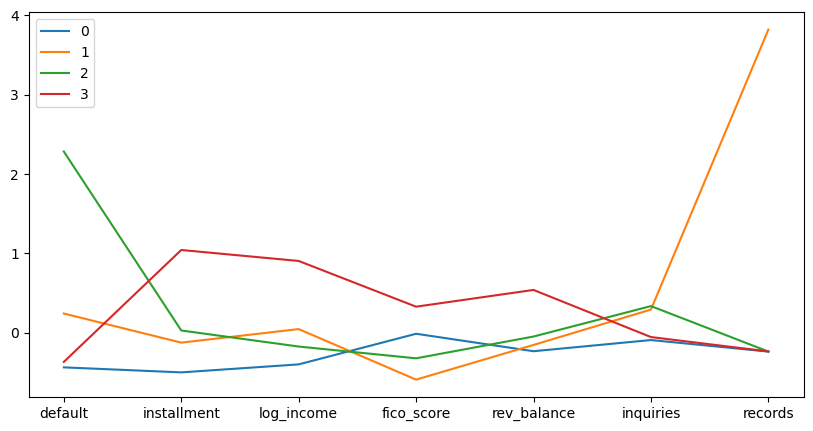

In [23]:
df_centroids.T.plot(figsize = (10,5))

### ii. What’s the % reduction in the sum of squared distances when we go from k=1 (baseline) to k=4?

In [24]:
k=1

In [25]:
clustering_kmeans1 = KMeans(n_clusters=k, n_init=100, random_state=886)
clustering_kmeans1.fit(standardized_df)

KMeans(n_clusters=1, n_init=100, random_state=886)

In [26]:
inertia2 = clustering_kmeans1.inertia_
inertia2

66612.0

In [27]:
perc_reduction_inertia = (inertia2 - inertia1)/inertia2
print(perc_reduction_inertia * 100,'%')

38.489395479385635 %


### Part (c)
Try to provide a simple description, or descriptive label, to each of the 4 clusters you’ve identified in part (b).

### Looking at the Parallel plot above, we can conclude the following:

#### Cluster 0 refers to loans with lowest number of defaults, low revolving balance and fewer number of inquiries.
#### Cluster 1 refers to loans with highest number of derogatory public records and customers with lowest FICO Scores.
#### Cluster 2 refers to loans with highest number of defaults.
#### Cluster 3 refers to loans with high monthly installments, customers with high income, FICO Scores and revolving balance.

### Part (d)
Construct an elbow plot for values of k between 1 and 10. Comment on where a clear "elbow" point exists on the plot.

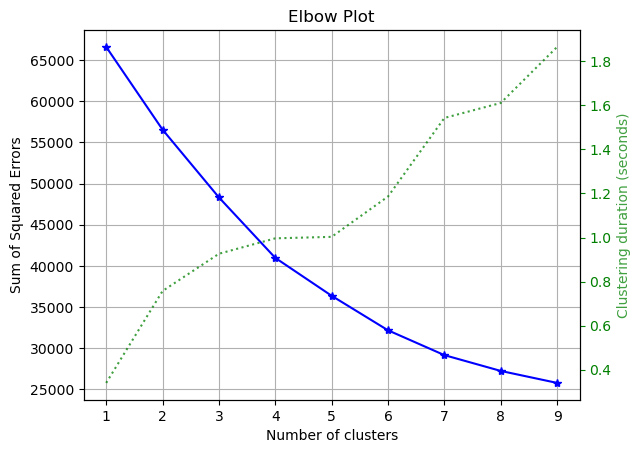

In [28]:
skplt.cluster.plot_elbow_curve(clustering_kmeans, standardized_df, cluster_ranges=range(1, 10))
plt.show()

### Looking at the plot, we can say that there is no clear elbow point that exists and for sure a judgement is required to decide on the number of clusters k. 

----

### Problem 2 (60 points)

In this problem I ask you to analyze data on Covid-19 vaccination rates in the US in terms of 15 census variables used by the CDC to determine the degree of social vulnerability of each of 3,141 counties. This is the same dataset you've seen in the final exam for 46-881. 

I'm providing a random 70-30 train / test split of the counties in two data files available on Canvas accompanying this deliverable: <vaccination_trainset.csv> and <vaccination_testset.csv>. Each row corresponds to a unique county. A data dictionary is provided below: 

| Column name |	Description |
| :-----------| :------------------|
| STATE	      | State abbreviation |
| COUNTY	  | County name        |
| EP_POV      |	Percentage of persons below poverty estimate|
| EP_UNEMP    |	Unemployment Rate estimate|
| EP_PCI      |	Per capita income estimate|
| EP_NOHSDP   |	Percentage of persons with no high school diploma (age 25+) estimate|
| EP_AGE65    |	Percentage of persons aged 65 and older estimate|
| EP_AGE17    |	Percentage of persons aged 17 and younger estimate|
| EP_DISABL   |	Percentage of civilian noninstitutionalized population with a disability estimate|
| EP_SNGPNT   |	Percentage of single parent households with children under 18 estimate|
| EP_MINRTY   |	Percentage minority (all persons except white, non-Hispanic) estimate|
| EP_LIMENG   |	Percentage of persons (age 5+) who speak English "less than well" estimate|
| EP_MUNIT    |	Percentage of housing in structures with 10 or more units estimate|
| EP_MOBILE   |	Percentage of mobile homes estimate|
| EP_CROWD    |	Percentage of occupied housing units with more people than rooms estimate|
| EP_NOVEH    |	Percentage of households with no vehicle available estimate|
| EP_GROUPQ   |	Percentage of persons in group quarters estimate|
| V_PCT_65YRS |	Percent of population 65 years and older fully vaccinated| 

The data on vaccination rates is current as of October 14th, 2021. Approximately 395 of the 3,141 counties had at least one missing variable element and these counties have been deleted (possibly biasing the data, but do not worry about this for the purposes of this exam). More information on the data and its context is available on the CDC website.  

#### Part (a)
Use Scikit-Learn to construct a linear regression model on the train set with the percent of population 65 years and older fully vaccinated (V_PCT_65YRS) as the dependent variable and an appropriate selection of the 15 social vulnerability variables (those with the “EP” prefix) as the independent variables. Outline clearly the procedure you followed to arrive at your final regression model starting from the data provided. Print the intercept and model coefficients.

In [29]:
df_train = pd.read_csv("vaccination_trainset.csv")
df_test = pd.read_csv("vaccination_testset.csv")

In [30]:
y_train = df_train["V_PCT_65YRS"]

In [31]:
X_train = df_train.drop(["V_PCT_65YRS","STATE","COUNTY"],axis=1)

In [32]:
lr_mod = LinearRegression()
lr_mod.fit(X_train, y_train)

LinearRegression()

In [33]:
lr_mod.intercept_

74.26452581828822

In [34]:
lr_mod.coef_

array([-2.47279342e-01,  8.77528058e-01,  6.63715090e-05, -6.47085930e-01,
       -2.65582039e-01, -7.20937380e-03,  4.07188387e-01,  7.53830803e-01,
       -8.08392315e-02,  6.20666589e-01,  2.77658187e-01, -5.25330951e-01,
        5.17547465e-01, -1.34258707e-01,  9.65427524e-02])

In [35]:
lr_mod.score(X_train, y_train)

0.24140600174780635

#### Part (b)
What is the out-of-sample (i.e. test set) RMSE?

In [36]:
y_test = df_test["V_PCT_65YRS"]

In [37]:
X_test = df_test.drop(["V_PCT_65YRS","STATE","COUNTY"],axis=1)

In [38]:
lr_mod_predictions = lr_mod.predict(X_test)
mean_squared_error(y_test, lr_mod_predictions, squared=False)

15.005259346078187

#### Part (c)
Repeat the prediction of Parts (a) and (b) but with a KNN algorithm (with k = 5). What is the out-of-sample (i.e. test set) RMSE in this case?   

In [39]:
scaler = StandardScaler()
scaler.fit(X_train)
# Standardize the train set
standardized_X_train = X_train.copy()
standardized_train_array = scaler.transform(standardized_X_train)
standardized_X_train[:] = standardized_train_array
# Standardize the test set
standardized_X_test = X_test.copy()
standardized_test_array = scaler.transform(standardized_X_test)
standardized_X_test[:] = standardized_test_array

In [40]:
k = 5
knn_mod = KNeighborsRegressor(n_neighbors=k)
knn_mod.fit(standardized_X_train, y_train)
knn_pred = knn_mod.predict(standardized_X_test)
mean_squared_error(y_test, knn_pred, squared=False)

15.529295803588127

----